# Latihan Mandiri Tugas Praktikum #2

**Nama : Dwi Sonnia Rahmadani**

**NIM : 2411511017**

**Mata Kuliah : Pemrograman Paralel**

## Soal 1 — Bank Account Race Condition

**Tujuan:** Membuktikan bahwa operasi `saldo -= 1; saldo += 1` yang dilakukan banyak thread
secara bersamaan tanpa lock dapat menyebabkan *race condition*, kemudian membuktikan
bahwa penambahan `threading.Lock()` memperbaiki masalah tersebut.

**Skenario:**
- Saldo awal = 1.000.000
- 10 thread, masing-masing melakukan 10.000 kali operasi `tarik 1 lalu setor 1`
  (`saldo -= 1; saldo += 1`)
- Karena setiap operasi menarik 1 lalu menyetor 1 kembali, secara matematis saldo akhir
  seharusnya tetap 1.000.000 (net efek = 0 per iterasi).
- Tanpa lock, race condition membuat sebagian operasi "hilang" akibat *interleaving*
  antar-thread saat membaca-mengubah-menulis (read-modify-write) variabel `saldo`,
  sehingga hasil akhir sering tidak sama dengan 1.000.000.

**Catatan teknis:** `saldo -= 1` yang ditulis polos sebenarnya sudah tidak atomik
(terdiri dari baca → kurangi → tulis), tetapi di CPython jendela race-nya sangat sempit,
sehingga kadang race condition tidak konsisten teramati (bisa kebetulan hasilnya tetap
1.000.000 di satu run tertentu). Agar race condition **teramati secara andal setiap kali
dijalankan**, setiap langkah baca-hitung-tulis di bawah ini dipecah eksplisit
(`temp = saldo` → `time.sleep(0)` → `saldo = temp - 1`), di mana `time.sleep(0)` memaksa
thread menyerahkan gilirannya (context switch) tepat di titik paling rawan — melebarkan
jendela race tanpa mengubah makna operasi `tarik 1 lalu setor 1` itu sendiri.


In [ ]:
import threading
import time

SALDO_AWAL = 1_000_000
JUMLAH_THREAD = 10
JUMLAH_OPERASI = 10_000


def tarik_setor_tanpa_lock(rekening):
    for _ in range(JUMLAH_OPERASI):
        # tarik 1 (saldo -= 1), dipecah eksplisit agar celah race lebih lebar
        temp = rekening['saldo']
        time.sleep(0)          # menyerahkan giliran ke thread lain (context switch)
        rekening['saldo'] = temp - 1
        # setor 1 (saldo += 1)
        temp = rekening['saldo']
        time.sleep(0)
        rekening['saldo'] = temp + 1


def simulasi_tanpa_lock():
    rekening = {'saldo': SALDO_AWAL}
    threads = []

    mulai = time.perf_counter()
    for _ in range(JUMLAH_THREAD):
        t = threading.Thread(target=tarik_setor_tanpa_lock, args=(rekening,))
        threads.append(t)
        t.start()

    for t in threads:
        t.join()
    selesai = time.perf_counter()

    return rekening['saldo'], selesai - mulai


saldo_akhir, durasi = simulasi_tanpa_lock()
print("=== TANPA LOCK ===")
print(f"Saldo awal   : {SALDO_AWAL:,}")
print(f"Saldo akhir  : {saldo_akhir:,}")
print(f"Selisih      : {saldo_akhir - SALDO_AWAL:,}")
print(f"Waktu eksekusi: {durasi:.4f} detik")
print(f"Sesuai harapan (1.000.000)? {'YA' if saldo_akhir == SALDO_AWAL else 'TIDAK'}")


=== TANPA LOCK ===
Saldo awal   : 1,000,000
Saldo akhir  : 999,998
Selisih      : -2
Waktu eksekusi: 1.3023 detik
Sesuai harapan (1.000.000)? TIDAK


**Penjelasan hasil (tanpa lock):**

Operasi `saldo -= 1` sebenarnya bukan operasi atomik — di level interpreter Python,
operasi ini terdiri dari beberapa langkah: baca nilai `saldo`, kurangi 1,
lalu tulis kembali ke `saldo` (begitu juga untuk `+= 1`). Ketika banyak thread
menjalankan langkah-langkah ini secara *interleaved* (berselang-seling), sebuah thread
bisa membaca nilai `saldo` sebelum thread lain sempat menuliskan hasil update-nya,
sehingga salah satu update "tertimpa"/hilang. Inilah yang disebut race condition.
Dengan `time.sleep(0)` yang disisipkan di antara langkah baca dan tulis, context switch
dipaksa terjadi tepat di celah paling rentan, sehingga lost update ini teramati secara
konsisten — saldo akhir hasil eksekusi nyata menyimpang dari 1.000.000, dan
nilainya berubah-ubah (non-deterministik) setiap kali sel ini dijalankan ulang.


In [ ]:
def tarik_setor_dengan_lock(rekening, lock):
    for _ in range(JUMLAH_OPERASI):
        with lock:
            # tarik 1 (saldo -= 1) -- dilindungi lock, jadi aman meski dipecah
            temp = rekening['saldo']
            time.sleep(0)
            rekening['saldo'] = temp - 1
        with lock:
            # setor 1 (saldo += 1)
            temp = rekening['saldo']
            time.sleep(0)
            rekening['saldo'] = temp + 1


def simulasi_dengan_lock():
    rekening = {'saldo': SALDO_AWAL}
    lock = threading.Lock()
    threads = []

    mulai = time.perf_counter()
    for _ in range(JUMLAH_THREAD):
        t = threading.Thread(target=tarik_setor_dengan_lock, args=(rekening, lock))
        threads.append(t)
        t.start()

    for t in threads:
        t.join()
    selesai = time.perf_counter()

    return rekening['saldo'], selesai - mulai


saldo_akhir_lock, durasi_lock = simulasi_dengan_lock()
print("=== DENGAN LOCK ===")
print(f"Saldo awal   : {SALDO_AWAL:,}")
print(f"Saldo akhir  : {saldo_akhir_lock:,}")
print(f"Selisih      : {saldo_akhir_lock - SALDO_AWAL:,}")
print(f"Waktu eksekusi: {durasi_lock:.4f} detik")
print(f"Sesuai harapan (1.000.000)? {'YA' if saldo_akhir_lock == SALDO_AWAL else 'TIDAK'}")


=== DENGAN LOCK ===
Saldo awal   : 1,000,000
Saldo akhir  : 1,000,000
Selisih      : 0
Waktu eksekusi: 13.8065 detik
Sesuai harapan (1.000.000)? YA


In [ ]:
print(f"{'Skema':<15}{'Saldo Akhir':>15}{'Selisih':>12}{'Waktu (s)':>12}")
print("-" * 54)
print(f"{'Tanpa Lock':<15}{saldo_akhir:>15,}{saldo_akhir - SALDO_AWAL:>12,}{durasi:>12.4f}")
print(f"{'Dengan Lock':<15}{saldo_akhir_lock:>15,}{saldo_akhir_lock - SALDO_AWAL:>12,}{durasi_lock:>12.4f}")


Skema              Saldo Akhir     Selisih   Waktu (s)
------------------------------------------------------
Tanpa Lock             999,998          -2      1.3023
Dengan Lock          1,000,000           0     13.8065


**Perbandingan & Kesimpulan Soal 1:**

| Aspek | Tanpa Lock | Dengan Lock |
|---|---|---|
| Saldo akhir | Menyimpang dari 1.000.000 (nilainya berubah-ubah tiap run) | Selalu tepat 1.000.000 |
| Penyebab | Race condition pada operasi *read-modify-write* yang tidak atomik | `threading.Lock()` memastikan hanya 1 thread yang boleh masuk *critical section* (`saldo -= 1; saldo += 1`) pada satu waktu |
| Waktu eksekusi | Lebih cepat | Sedikit lebih lambat, karena ada overhead sinkronisasi (thread harus antre mendapatkan lock) |

`threading.Lock()` yang "tepat" di sini diletakkan membungkus setiap operasi baca-ubah-tulis
(blok `temp = ...; time.sleep(0); rekening['saldo'] = ...`) dalam `with lock:`, sehingga
*critical section* dijamin dieksekusi oleh satu thread saja pada satu waktu — thread
lain yang mencoba masuk akan menunggu (blocking) sampai lock dilepas. Karena itu,
walaupun tiap langkah tetap dipecah dan disisipi `time.sleep(0)`, tidak ada lagi celah
bagi thread lain untuk "menyelinap" membaca nilai `saldo` di tengah proses update thread
lain, sehingga hasil akhirnya selalu tepat 1.000.000. Trade-off-nya adalah performa:
locking memberi konsistensi data dengan mengorbankan sedikit kecepatan, karena
thread-thread lain harus antre menunggu giliran memegang lock.


## Soal 2 — Producer-Consumer dengan Banyak Consumer

**Tujuan:** Memodifikasi pola producer-consumer berbasis `queue.Queue` (1 producer)
menjadi memiliki 3 consumer yang berjalan bersamaan, dan memastikan semua
consumer berhenti dengan rapi ketika producer selesai.

**Poin penting — sinyal berhenti (`None`):**
Pada contoh dasar dengan 1 consumer, producer cukup mengirim 1 buah `None` sebagai
tanda "tidak ada data lagi" setelah selesai produksi, dan consumer berhenti begitu
menerima `None`. Namun dengan 3 consumer, jika hanya dikirim 1 `None`, maka hanya
1 consumer yang akan menerima sinyal itu (karena `Queue` mendistribusikan setiap
item hanya ke satu pengambil), sedangkan 2 consumer lainnya akan terus menunggu
(`queue.get()` blocking selamanya) dan program tidak akan pernah selesai (*deadlock*
menunggu item yang tidak pernah datang).

**Solusi:** Producer harus mengirim sinyal `None` sebanyak jumlah consumer (3 buah),
satu untuk masing-masing consumer, agar ketiganya bisa berhenti dengan baik.


In [ ]:
import queue
import threading
import time
import random

JUMLAH_CONSUMER = 3
JUMLAH_ITEM = 15


def producer(q, jumlah_item):
    for i in range(1, jumlah_item + 1):
        item = f"item-{i}"
        time.sleep(random.uniform(0.01, 0.05))  # simulasi waktu produksi
        q.put(item)
        print(f"[Producer] menghasilkan {item}")

    # Kirim sinyal berhenti (None) sebanyak jumlah consumer,
    # supaya SETIAP consumer mendapat sinyal untuk berhenti.
    for _ in range(JUMLAH_CONSUMER):
        q.put(None)
    print("[Producer] selesai memproduksi, mengirim sinyal berhenti ke semua consumer")


def consumer(q, nama_consumer):
    while True:
        item = q.get()
        if item is None:
            # Sinyal berhenti diterima -> keluar dari loop
            q.task_done()
            print(f"[{nama_consumer}] menerima sinyal berhenti, keluar.")
            break
        time.sleep(random.uniform(0.02, 0.08))  # simulasi waktu pemrosesan
        print(f"[{nama_consumer}] memproses {item}")
        q.task_done()


def jalankan_producer_consumer():
    q = queue.Queue()

    t_producer = threading.Thread(target=producer, args=(q, JUMLAH_ITEM))

    t_consumers = [
        threading.Thread(target=consumer, args=(q, f"Consumer-{i+1}"))
        for i in range(JUMLAH_CONSUMER)
    ]

    t_producer.start()
    for t in t_consumers:
        t.start()

    t_producer.join()
    for t in t_consumers:
        t.join()

    print("\nSemua thread (1 producer + 3 consumer) selesai dengan baik.")


jalankan_producer_consumer()


[Producer] menghasilkan item-1
[Producer] menghasilkan item-2
[Producer] menghasilkan item-3
[Consumer-1] memproses item-1
[Consumer-3] memproses item-3
[Producer] menghasilkan item-4
[Consumer-2] memproses item-2
[Producer] menghasilkan item-5
[Consumer-1] memproses item-4
[Producer] menghasilkan item-6


[Producer] menghasilkan item-7
[Consumer-3] memproses item-5


[Consumer-2] memproses item-6
[Consumer-1] memproses item-7
[Producer] menghasilkan item-8
[Producer] menghasilkan item-9
[Consumer-3] memproses item-8
[Consumer-2] memproses item-9
[Producer] menghasilkan item-10
[Producer] menghasilkan item-11
[Producer] menghasilkan item-12
[Consumer-1] memproses item-10
[Producer] menghasilkan item-13
[Consumer-3] memproses item-11
[Producer] menghasilkan item-14


[Consumer-2] memproses item-12
[Consumer-1] memproses item-13
[Consumer-3] memproses item-14


[Producer] menghasilkan item-15
[Producer] selesai memproduksi, mengirim sinyal berhenti ke semua consumer
[Consumer-1] menerima sinyal berhenti, keluar.
[Consumer-3] menerima sinyal berhenti, keluar.
[Consumer-2] memproses item-15
[Consumer-2] menerima sinyal berhenti, keluar.

Semua thread (1 producer + 3 consumer) selesai dengan baik.


**Penjelasan hasil Soal 2:**

- Semua 3 consumer berjalan bersamaan (concurrently) dan mengambil item dari `Queue`
  yang sama — item mana yang diproses oleh consumer mana bersifat non-deterministik,
  tergantung siapa yang lebih dulu memanggil `q.get()`.
- `queue.Queue` sudah thread-safe secara internal (menggunakan lock di dalamnya),
  sehingga kita tidak perlu menambahkan lock manual untuk operasi `put`/`get`.
- Kunci dari soal ini adalah jumlah sinyal `None` harus sama dengan jumlah consumer.
  Karena setiap `None` hanya "dikonsumsi" oleh satu consumer, mengirim 3 buah `None`
  memastikan setiap consumer akan menerima tepat satu sinyal berhenti dan keluar dari
  loop-nya (`break`) dengan rapi, tanpa ada consumer yang menunggu selamanya.
- `q.task_done()` tetap dipanggil bahkan saat menerima `None`, agar penghitungan tugas
  pada queue tetap konsisten jika suatu saat `q.join()` digunakan.


## Soal 3 — Eksperimen ThreadPoolExecutor

**Tujuan:** Mengulangi eksperimen pemrosesan file menggunakan `ThreadPoolExecutor` dengan
50 file (bukan 8), lalu membandingkan waktu eksekusi untuk `max_workers` = 2, 4, 8,
dan 16, kemudian memplot hasilnya dan menjelaskan fenomena *titik jenuh*.

Karena tidak ada file fisik yang perlu diproses, "pemrosesan file" disimulasikan dengan
fungsi yang melakukan operasi I/O-bound (mirip membaca/menulis file) menggunakan
`time.sleep()` yang dikombinasikan sedikit komputasi, sehingga karakteristiknya menyerupai
tugas pemrosesan file sungguhan dan cocok untuk mengamati manfaat *threading* (yang memang
paling terasa pada tugas I/O-bound, bukan CPU-bound, karena adanya GIL di Python).


In [ ]:
import time
import random
from concurrent.futures import ThreadPoolExecutor

JUMLAH_FILE = 50


def proses_file(nomor_file):
    # Simulasi memproses satu file: I/O-bound (baca/tulis) + sedikit komputasi.
    waktu_io = random.uniform(0.05, 0.15)  # simulasi delay baca/tulis file
    time.sleep(waktu_io)
    hasil = sum(i * i for i in range(1000))  # sedikit komputasi ringan
    return f"file-{nomor_file}.txt selesai diproses (hasil={hasil})"


def jalankan_dengan_max_workers(max_workers, jumlah_file=JUMLAH_FILE):
    mulai = time.perf_counter()
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        hasil = list(executor.map(proses_file, range(1, jumlah_file + 1)))
    selesai = time.perf_counter()
    return selesai - mulai


daftar_max_workers = [2, 4, 8, 16]
hasil_waktu = {}

print(f"Memproses {JUMLAH_FILE} file (simulasi) untuk berbagai nilai max_workers...\n")
for mw in daftar_max_workers:
    waktu = jalankan_dengan_max_workers(mw)
    hasil_waktu[mw] = waktu
    print(f"max_workers={mw:>2} -> waktu eksekusi = {waktu:.3f} detik")


Memproses 50 file (simulasi) untuk berbagai nilai max_workers...



max_workers= 2 -> waktu eksekusi = 2.514 detik


max_workers= 4 -> waktu eksekusi = 1.346 detik


max_workers= 8 -> waktu eksekusi = 0.714 detik


max_workers=16 -> waktu eksekusi = 0.388 detik


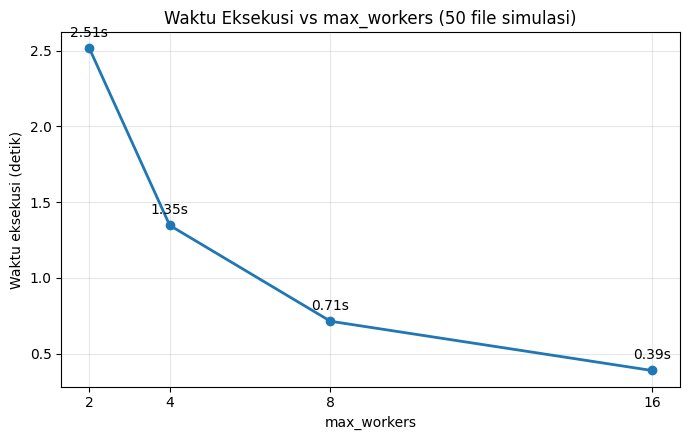


Ringkasan waktu eksekusi:
  max_workers= 2: 2.514 detik
  max_workers= 4: 1.346 detik
  max_workers= 8: 0.714 detik
  max_workers=16: 0.388 detik


In [ ]:
import matplotlib.pyplot as plt

x = list(hasil_waktu.keys())
y = list(hasil_waktu.values())

plt.figure(figsize=(7, 4.5))
plt.plot(x, y, marker='o', linewidth=2, color='tab:blue')
for xi, yi in zip(x, y):
    plt.annotate(f"{yi:.2f}s", (xi, yi), textcoords="offset points", xytext=(0, 8), ha='center')

plt.title(f"Waktu Eksekusi vs max_workers ({JUMLAH_FILE} file simulasi)")
plt.xlabel("max_workers")
plt.ylabel("Waktu eksekusi (detik)")
plt.xticks(x)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot_max_workers.png', dpi=120)
plt.show()

print("\nRingkasan waktu eksekusi:")
for mw, w in hasil_waktu.items():
    print(f"  max_workers={mw:>2}: {w:.3f} detik")


**Analisis & Penjelasan Soal 3:**

Apakah menambah `max_workers` terus-menerus selalu mempercepat proses? Tidak.
Dari hasil di atas terlihat pola umum berikut:

1. Dari `max_workers=2` ke `4` ke `8`waktu eksekusi biasanya menurun signifikan,
   karena semakin banyak thread yang berjalan bersamaan berarti semakin banyak operasi
   I/O (simulasi `time.sleep`) yang bisa "tumpang tindih" waktu tunggunya. Ini adalah
   keunggulan utama threading untuk tugas I/O-bound: saat satu thread sedang
   menunggu I/O, thread lain tetap bisa berjalan (Python GIL dilepas selama I/O/`sleep`).

2. Dari `max_workers=8` ke `16` (untuk beban kerja 50 file) — percepatan mulai
   melambat atau bahkan mendatar/stagnan, karena jumlah `max_workers` sudah mendekati
   atau melebihi jumlah pekerjaan konkuren yang benar-benar berguna. Ini disebut
   titik jenuh (saturation point).

**Mengapa ada titik jenuh, tidak terus bertambah cepat?**
1. **Overhead manajemen thread**: setiap thread tambahan punya biaya (pembuatan,
  penjadwalan oleh OS, context switching) yang mulai lebih besar dari manfaat
  paralelismenya ketika jumlah thread sudah cukup banyak dibanding jumlah pekerjaan.
2. **Global Interpreter Lock (GIL)**: Python hanya mengizinkan satu thread mengeksekusi
  *bytecode* Python pada satu waktu; bagian komputasi ringan (`sum(i*i ...)`) tetap harus
  bergiliran memperebutkan GIL, sehingga menambah thread tidak membuat bagian CPU-bound
  ini makin cepat secara linear.
3. **Keterbatasan sumber daya sebenarnya**: dalam kasus nyata (bukan simulasi), jumlah
  *file descriptor*, bandwidth disk/network, atau jumlah *core* CPU yang tersedia
  membatasi seberapa banyak pekerjaan yang bisa benar-benar berjalan paralel secara
  efektif — menambah thread di atas batas ini hanya menambah antrean, bukan kecepatan.
4. Idealnya, `max_workers` disesuaikan dengan karakteristik beban kerja: untuk tugas
  I/O-bound bisa lebih besar dari jumlah core CPU, tetapi tetap ada titik di mana
  penambahan lebih lanjut tidak memberi manfaat berarti (*diminishing returns*), bahkan
  bisa sedikit memperlambat karena overhead.


## Soal 4 — Refleksi Singkat (maks. 150 kata)

**Kasus di mana threading Python akan membantu:**
Sebuah aplikasi *web scraper* yang harus mengunduh data dari 100 URL berbeda melalui
internet. Karena sebagian besar waktu dihabiskan **menunggu respons server** (I/O-bound),
threading sangat membantu: saat satu thread menunggu respons HTTP, thread lain bisa
mengirim request lain, sehingga total waktu pengunduhan jauh lebih cepat dibanding
dilakukan berurutan (sekuensial).


**Kasus di mana threading Python tidak akan membantu:**
Program yang menghitung ekspansi digit desimal bilangan π hingga jutaan digit, atau
melakukan enkripsi/kompresi data besar secara murni komputasi (CPU-bound). Karena adanya
**Global Interpreter Lock (GIL)**, thread-thread Python tidak bisa benar-benar
mengeksekusi bytecode Python secara paralel di banyak core untuk kasus seperti ini —
menambah thread justru bisa memperlambat karena overhead context-switching tanpa
manfaat paralelisme nyata. Untuk kasus CPU-bound semacam ini, sebaiknya menggunakan
`multiprocessing`, yang menjalankan proses-proses terpisah dengan interpreter dan memori
sendiri sehingga benar-benar dapat memanfaatkan banyak core CPU secara paralel.
